In [1]:
import sqlite3
import pandas as pd
import numpy as np
from tqdm import tqdm
import json

In [4]:
SQLITE_PATH = "dev_ai_articles_full.sqlite"

DEV_COLUMN_CONFIG = {
    "id": "id",           # primary key column
    "title": "title",     # article title column
    "body": "body_text",       # article body/content column (set to None if not available)
}
dev_articles = "topic labeled articles"

# Number of characters per chunk for each article (split long articles into multiple chunks to avoid hitting model context length limits)
CHUNK_CHARS = 2500

# Batch size for zero-shot classification (lower if you run out of RAM)
CLASSIFICATION_BATCH_SIZE = 32

In [5]:
conn = sqlite3.connect(SQLITE_PATH)
cursor = conn.cursor()

In [9]:
id_col = DEV_COLUMN_CONFIG["id"]
title_col = DEV_COLUMN_CONFIG["title"]
body_col = DEV_COLUMN_CONFIG["body"]

query = f'SELECT * FROM "{dev_articles}"'

df = pd.read_sql_query(query, conn)


# Vader sentiment

In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


sia = SentimentIntensityAnalyzer()


In [18]:

def vader_sentiment(text):
    score = sia.polarity_scores(text[:2000])["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"


non_tech_df = df.copy()

In [19]:
non_tech_df["sentiment"] = non_tech_df["combined_text"].apply(vader_sentiment)

In [20]:

print("Sentiment distribution:")
print(non_tech_df["sentiment"].value_counts())

Sentiment distribution:
sentiment
positive    4293
negative    1085
neutral       20
Name: count, dtype: int64


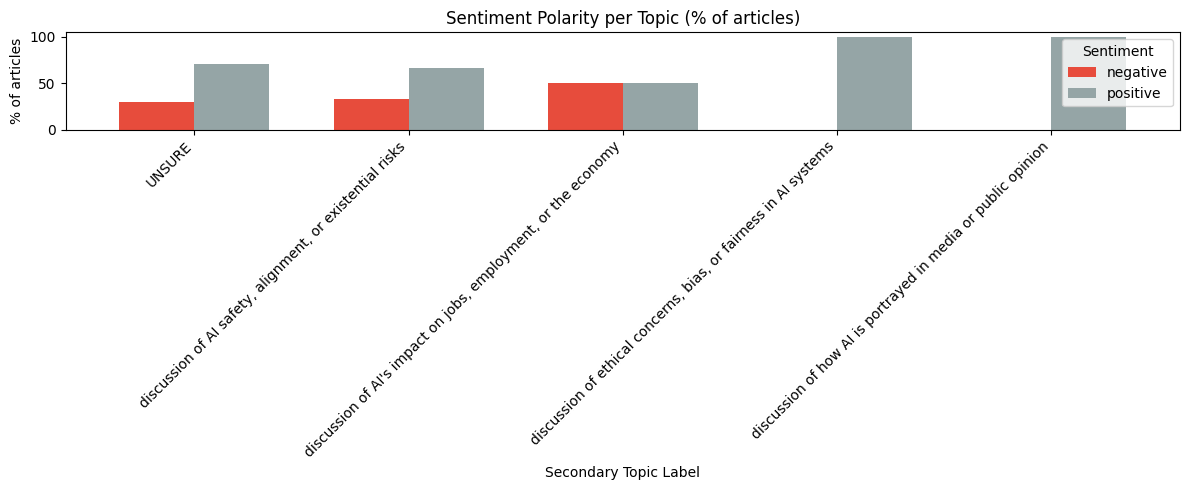

sentiment,negative,positive
secondary_label,,
UNSURE,29.411765,70.588235
"discussion of AI safety, alignment, or existential risks",33.333333,66.666667
"discussion of AI's impact on jobs, employment, or the economy",50.000000,50.000000
"discussion of ethical concerns, bias, or fairness in AI systems",0.000000,100.000000
discussion of how AI is portrayed in media or public opinion,0.000000,100.000000


In [22]:
import matplotlib.pyplot as plt
# Sentiment breakdown per secondary label
has_label = non_tech_df[non_tech_df["secondary_label"] != ""]
sent_cross = has_label.groupby(["secondary_label", "sentiment"]).size().unstack(fill_value=0)
sent_pct = sent_cross.div(sent_cross.sum(axis=1), axis=0) * 100

sent_pct.plot(kind="bar", figsize=(12, 5), color=["#e74c3c", "#95a5a6", "#2ecc71"], width=0.7)
plt.title("Sentiment Polarity per Topic (% of articles)")
plt.xlabel("Secondary Topic Label")
plt.ylabel("% of articles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()
sent_pct

# TextBlob

In [23]:

from textblob import TextBlob
import pandas as pd

def textblob_sentiment(text: str):
    if not isinstance(text, str) or not text.strip():
        return 0.0, 0.0, "neutral"

    blob = TextBlob(text)
    polarity = blob.sentiment.polarity      # range: [-1, 1]
    subjectivity = blob.sentiment.subjectivity  # range: [0, 1]

    if polarity > 0.05:
        label = "positive"
    elif polarity < -0.05:
        label = "negative"
    else:
        label = "neutral"

    return polarity, subjectivity, label



non_tech_df[["tb_polarity", "tb_subjectivity", "tb_sentiment"]] = non_tech_df["combined_text"].apply(
	lambda x: pd.Series(textblob_sentiment(x))
)


KeyError: 'sentiment'